# Multi-instance 바둑판(그리드) 합성 이미지 생성

목적:
- `daily` 폴더에서 이미지 `n`개를 선택(랜덤/명시)
- 2x2(4분면) 또는 일반 그리드로 합성 이미지 생성
- 자동분류 multi-instance 테스트용 입력 이미지 저장


In [1]:
from pathlib import Path
import math
import random
from datetime import datetime
from PIL import Image, ImageOps, ImageDraw

# ===== 사용자 설정 =====
SOURCE_DIR = Path('/workspace/PoC/dogface_fastapi_poc_qdrant/data/images_for_test/dc_001/iphoneX/pictures/daily')
OUT_DIR = Path('/workspace/PoC/dogface_fastapi_poc_qdrant/data/images_for_test/dc_001/iphoneX/pictures/synthetic_multi')

# 선택 모드: 'random' | 'explicit'
SELECT_MODE = 'random'

# 합성할 이미지 개수 (예: 4 -> 1,2,3,4 분면)
N_IMAGES = 4

# explicit 모드일 때 사용할 파일명(또는 절대경로)
EXPLICIT_IMAGES = [
    'daily_001.jpg',
    'daily_002.jpg',
    'daily_003.jpg',
    'daily_004.jpg',
]

# 타일(칸) 크기
TILE_SIZE = (640, 640)

# 그리드 강제 지정(예: (2,2)); None이면 자동(sqrt 기반)
FORCE_GRID = (2, 2) if N_IMAGES == 4 else None

# 바둑판 배경색
BG_COLOR = (18, 18, 18)

# 재현 가능한 랜덤 선택을 원하면 정수로 지정
SEED = 42

assert SOURCE_DIR.exists(), f'SOURCE_DIR not found: {SOURCE_DIR}'
OUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
def list_image_files(src: Path):
    exts = {'.jpg', '.jpeg', '.png', '.webp'}
    return sorted([p for p in src.iterdir() if p.is_file() and p.suffix.lower() in exts])

def resolve_explicit_paths(items, src: Path):
    resolved = []
    for it in items:
        p = Path(it)
        if not p.is_absolute():
            p = src / p
        if not p.exists():
            raise FileNotFoundError(f'Not found: {p}')
        resolved.append(p)
    return resolved

def choose_images(src: Path, mode: str, n: int, explicit_items, seed=None):
    files = list_image_files(src)
    if len(files) < n:
        raise ValueError(f'Not enough images in {src}: {len(files)} < {n}')

    mode = mode.lower().strip()
    if mode == 'explicit':
        chosen = resolve_explicit_paths(explicit_items, src)
        if len(chosen) != n:
            raise ValueError(f'EXPLICIT_IMAGES length({len(chosen)}) must equal N_IMAGES({n})')
        return chosen

    if mode == 'random':
        rng = random.Random(seed)
        return rng.sample(files, n)

    raise ValueError("SELECT_MODE must be 'random' or 'explicit'")

def fit_center_crop(img: Image.Image, target_size):
    img = img.convert('RGB')
    return ImageOps.fit(img, target_size, method=Image.Resampling.LANCZOS, centering=(0.5, 0.5))

def grid_shape(n: int, forced=None):
    if forced is not None:
        rows, cols = forced
        if rows * cols < n:
            raise ValueError(f'FORCE_GRID {forced} is too small for n={n}')
        return rows, cols
    cols = math.ceil(math.sqrt(n))
    rows = math.ceil(n / cols)
    return rows, cols

def make_checkerboard_collage(paths, tile_size=(640, 640), forced_grid=None, bg_color=(0,0,0), draw_index=True):
    n = len(paths)
    rows, cols = grid_shape(n, forced_grid)
    tw, th = tile_size
    canvas = Image.new('RGB', (cols * tw, rows * th), color=bg_color)

    placements = []
    for i, p in enumerate(paths):
        r = i // cols
        c = i % cols
        x = c * tw
        y = r * th

        with Image.open(p) as im:
            tile = fit_center_crop(im, (tw, th))
            canvas.paste(tile, (x, y))

        placements.append({
            'index': i + 1,
            'row': r + 1,
            'col': c + 1,
            'x': x,
            'y': y,
            'path': str(p)
        })

    if draw_index:
        draw = ImageDraw.Draw(canvas)
        for pl in placements:
            x = pl['x'] + 16
            y = pl['y'] + 16
            # 가독성을 위해 검은 배경 박스 + 흰 글자
            label = f"#{pl['index']}"
            draw.rectangle((x-8, y-8, x+72, y+36), fill=(0, 0, 0))
            draw.text((x, y), label, fill=(255, 255, 255))

    return canvas, placements, (rows, cols)


Saved: /workspace/PoC/dogface_fastapi_poc_qdrant/data/images_for_test/dc_001/iphoneX/pictures/synthetic_multi/checkerboard_n4_2x2_20260310_173235.jpg
Placements:
  #1: row=1 col=1 <- daily_011.jpg
  #2: row=1 col=2 <- daily_002.jpg
  #3: row=2 col=1 <- daily_001.jpg
  #4: row=2 col=2 <- daily_005.jpg


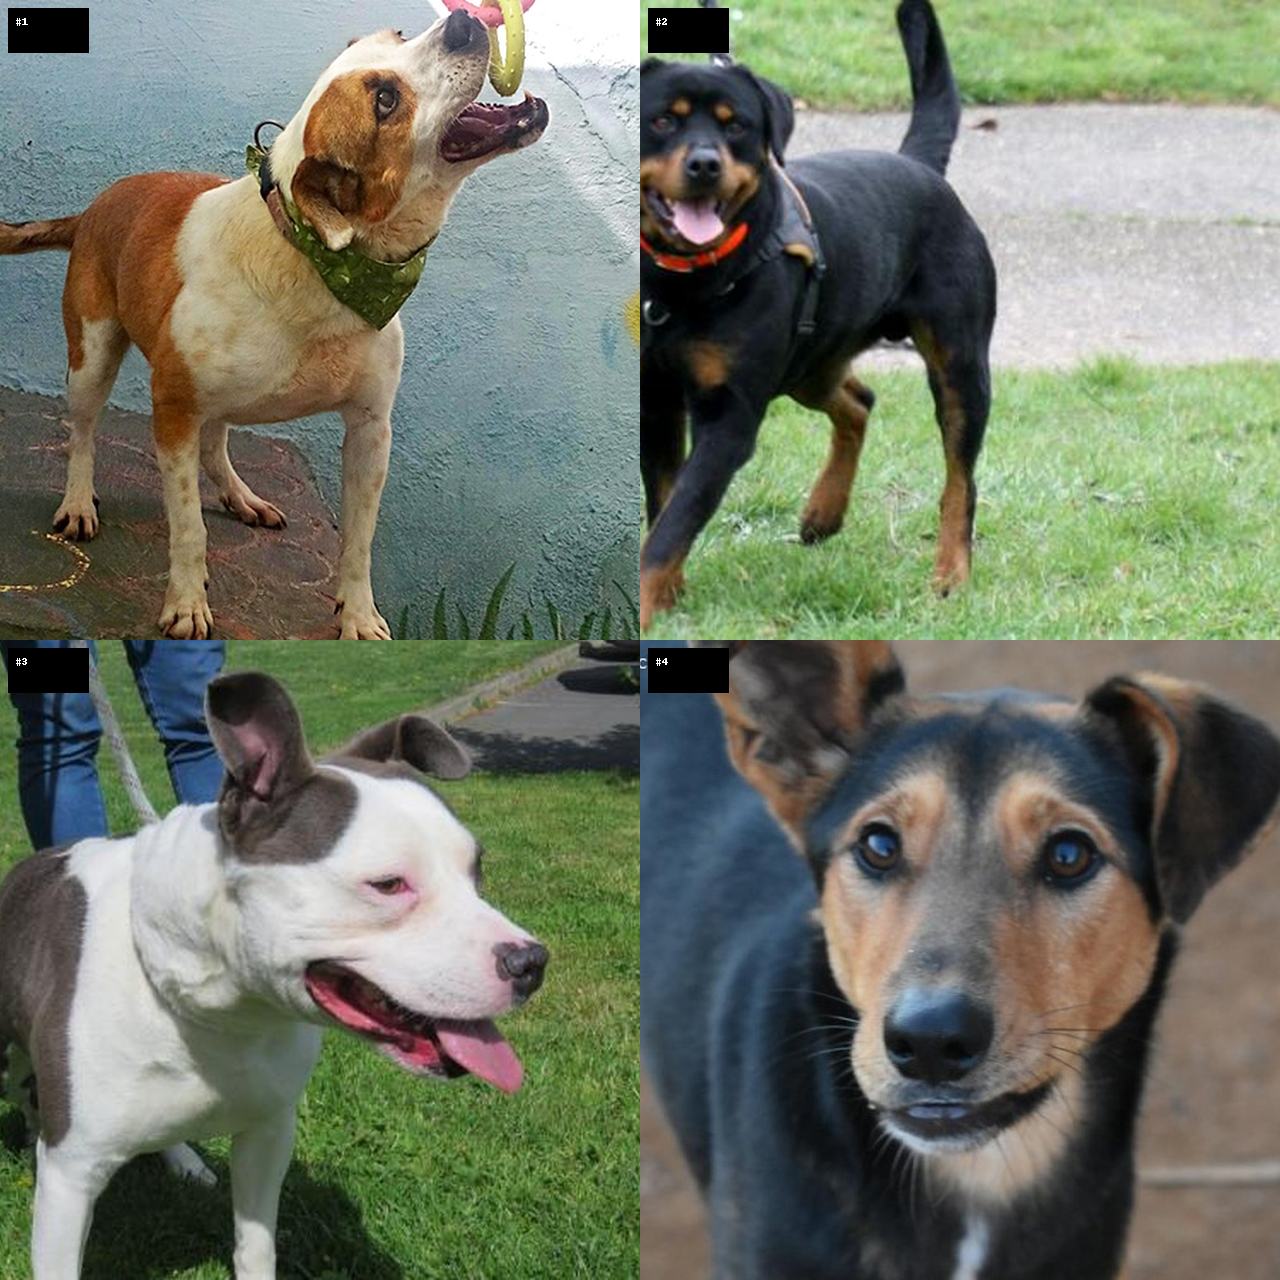

In [3]:
chosen = choose_images(SOURCE_DIR, SELECT_MODE, N_IMAGES, EXPLICIT_IMAGES, seed=SEED)
canvas, placements, shape = make_checkerboard_collage(
    chosen,
    tile_size=TILE_SIZE,
    forced_grid=FORCE_GRID,
    bg_color=BG_COLOR,
    draw_index=True,
)

ts = datetime.utcnow().strftime('%Y%m%d_%H%M%S')
out_name = f'checkerboard_n{N_IMAGES}_{shape[0]}x{shape[1]}_{ts}.jpg'
out_path = OUT_DIR / out_name
canvas.save(out_path, quality=95)

print(f'Saved: {out_path}')
print('Placements:')
for p in placements:
    print(f"  #{p['index']}: row={p['row']} col={p['col']} <- {Path(p['path']).name}")

canvas


## 사용 팁
- 4분면 고정 테스트: `N_IMAGES=4`, `FORCE_GRID=(2,2)`
- 랜덤 반복 생성: 마지막 셀만 여러 번 실행
- 특정 이미지 조합 테스트: `SELECT_MODE='explicit'` + `EXPLICIT_IMAGES` 수정
